In [18]:




from google.colab import drive 
drive.flush_and_unmount()
drive.mount('/content/drive')


import torch 
import torch.nn as nn 
import numpy as np
import matplotlib.pyplot as plt
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Mounted at /content/drive
Using device: cuda


In [19]:
data_path = '/content/drive/MyDrive/region_activity_with_rich_stim.npz'

data = np.load(data_path, allow_pickle=True)



Y_raw = data['Y']                        # (490816, 4) â€” firing rates for [VISal, VISl, VISp, VISpm]
U_raw = data['U_rich']                   # (490816, 15) â€” rich stimulus features
t_raw = data['time_bins']                # (490816,)   â€” time in seconds
regions = list(data['regions'])          # ['VISal', 'VISl', 'VISp', 'VISpm']
feature_names = list(data['feature_names'])  # 15 rich feature names
##-----Behavioral 
running_raw = data['running_speed']
pupil_raw = data['pupil_width']
# Downsample 10x: average every 10 bins (20ms * 10 = 200ms)
ds = 40
n_trim = (len(t_raw) // ds) * ds  # trim so it divides evenly
Y_ds = Y_raw[:n_trim].reshape(-1, ds, 4).mean(axis=1)    # (49081, 4)
U_ds = U_raw[:n_trim].reshape(-1, ds, 15).mean(axis=1)   # (49081, 15)
t_ds = t_raw[:n_trim].reshape(-1, ds).mean(axis=1)        # (49081,)
running_ds = running_raw[:n_trim].reshape(-1, ds).mean(axis=1)
pupil_ds = pupil_raw[:n_trim].reshape(-1, ds).mean(axis=1)

# Clip outliers: negative running = wheel decoder artifact, pupil > 99th pct = tracker glitch
running_ds = np.clip(running_ds, 0, None)
pupil_clip = np.percentile(pupil_ds, 99)
pupil_ds = np.clip(pupil_ds, 0, pupil_clip)
### Normalize time to [0, 1]

t_min, t_max = t_ds.min(), t_ds.max()
t_norm = (t_ds - t_min) / (t_max - t_min)

### Standard Scaler for stimulus 
from sklearn.preprocessing import StandardScaler
u_scaler= StandardScaler()
U_norm = u_scaler.fit_transform(U_ds)
beh_scaler = StandardScaler()
beh_norm = beh_scaler.fit_transform(
    np.column_stack([running_ds, pupil_ds])
)  # (N, 2)

beh_tensor = torch.tensor(beh_norm, dtype=torch.float32, device=device)  # (N, 2)
print(f"Behavioral: {beh_tensor.shape}")

#Min-mac [0,1] for Y
Y_min = Y_ds.min(axis=0, keepdims=True)
Y_max = Y_ds.max(axis=0, keepdims=True)
Y_norm = (Y_ds - Y_min) / (Y_max - Y_min + 1e-10)  # add small epsilon to avoid division by zero

# Convert to GPU tensors
t_tensor = torch.tensor(t_norm, dtype=torch.float32, device=device).unsqueeze(1)  # (N, 1)
Y_tensor = torch.tensor(Y_norm, dtype=torch.float32, device=device)               # (N, 4)
U_tensor = torch.tensor(U_norm, dtype=torch.float32, device=device)               # (N, 15)

print(f"Downsampled: {Y_ds.shape[0]} timesteps, dt=0.2s")
print(f"Regions: {regions}")
print(f"Tensors: t={t_tensor.shape}, Y={Y_tensor.shape}, U={U_tensor.shape}")

Exception ignored in: <function NpzFile.__del__ at 0x7c27055ed760>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 221, in close
    self.fid.close()
OSError: [Errno 107] Transport endpoint is not connected


Behavioral: torch.Size([12270, 2])
Downsampled: 12270 timesteps, dt=0.2s
Regions: [np.str_('VISal'), np.str_('VISl'), np.str_('VISp'), np.str_('VISpm')]
Tensors: t=torch.Size([12270, 1]), Y=torch.Size([12270, 4]), U=torch.Size([12270, 15])


In [20]:
class FourierFeatures(nn.Module):
    def __init__(self, n_freq = 64, min_freq=1.0, max_freq=1000.0):
        super().__init__()
        self.n_freq = n_freq
        freqs = torch.logspace(np.log10(min_freq), np.log10(max_freq), n_freq, device=device)  # (n_freq,)
        self.register_buffer('freqs', freqs)
        
    def forward(self, t):
        # t: (N, 1)
        # freqs: (n_freq,)
        # Compute outer product to get (N, n_freq)
        t_proj = 2 * np.pi * t @ self.freqs.unsqueeze(0)  # type: ignore # (N, n_freq)
        return torch.cat([torch.sin(t_proj), torch.cos(t_proj)], dim=-1)  # (N, 2*n_freq)
    
    
    
ff = FourierFeatures(n_freq=64).to(device)
test_out = ff(t_tensor[:5])
print(f"FourierFeatures: {t_tensor[:5].shape} -> {test_out.shape}")
# Expected: torch.Size([5, 1]) -> torch.Size([5, 128])

FourierFeatures: torch.Size([5, 1]) -> torch.Size([5, 128])


In [21]:
# Cell 4: Wilson-Cowan Physics Module â€” Full E/I dynamics
#
# The WC equations per region:
#   Ï„_E Â· dE/dt = -E + Ïƒ(w_EEÂ·E - w_EIÂ·I + w_uEÂ·u + b_E)
#   Ï„_I Â· dI/dt = -I + Ïƒ(w_IEÂ·E - w_IIÂ·I + b_I)
#
# Both E and I are now dynamic â€” predicted by the internal head of TrajectoryNet.
# The physics loss will constrain BOTH dE/dt and dI/dt.
#
# Even though we never observe I directly, the physics loss creates a chain:
#   1. Data loss forces E to match observed firing rates
#   2. Physics loss forces dE/dt to be consistent with WC(E, I, u)
#   3. Physics loss ALSO forces dI/dt to be consistent with WC(E, I)
#   4. So I is constrained indirectly: it must be whatever value makes
#      the WC equations hold for the E that's already pinned to data
#
# This is the power of PINNs for unobserved variables â€” the physics
# propagates information from observed (E) to unobserved (I).

class WilsonCowanPhysics(nn.Module):
    def __init__(self, n_regions=4, n_stim=15):
        super().__init__()

        # --- Time constants ---
        # Controls how fast each population responds.
        # Initialized at 1.0 (equal speed for E and I).
        # Wrapped in softplus in forward() to guarantee positivity.
        # If tau is large â†’ slow response (low-pass filter)
        # If tau is small â†’ fast response (tracks input tightly)
        self.tau_E = nn.Parameter(torch.full((n_regions,), 1.0))
        self.tau_I = nn.Parameter(torch.full((n_regions,), 1.0))

        # --- Local connection weights ---
        # These define the E/I interaction strength within each region.
        #
        # w_EE = 5.0: Eâ†’E recurrence. Strong, because cortical excitatory
        #   neurons have dense local recurrent connections (~80% of synapses).
        #   Initialized at 5.0 because w_EE * a/4 must be > 1 for oscillations
        #   (Hopf bifurcation condition from wc-dynamics-theory analysis).
        #   5.0 * 4.0/4 = 5.0 >> 1, safely oscillatory.
        self.w_EE = nn.Parameter(torch.full((n_regions,), 5.0))

        # w_EI = 4.0: Iâ†’E inhibition. The brake pedal. Must be strong enough
        #   to prevent E from saturating, but not so strong that it kills all activity.
        #   4.0 is slightly less than w_EE â€” so E can win locally (creating bumps)
        #   but I eventually catches up (creating the downswing).
        self.w_EI = nn.Parameter(torch.full((n_regions,), 4.0))

        # w_IE = 3.0: Eâ†’I excitation. How strongly E recruits I.
        #   This is the delayed negative feedback: E fires â†’ I fires a moment later
        #   â†’ I suppresses E. The delay comes from tau_I, not from w_IE itself.
        self.w_IE = nn.Parameter(torch.full((n_regions,), 3.0))

        # w_II = 1.0: Iâ†’I self-inhibition. Weak in real cortex â€”
        #   inhibitory interneurons don't strongly suppress each other
        #   (they mostly target E cells). Keeps I from exploding but
        #   doesn't dominate the dynamics.
        self.w_II = nn.Parameter(torch.full((n_regions,), 1.0))

        # --- Stimulus drive ---
        # w_uE: (15, 4) â€” how each stimulus feature drives each region's E population.
        # Initialized small (0.1 * randn) because:
        #   - We don't know a priori which stimulus features matter for which region
        #   - Large init would dominate the WC dynamics before they can establish
        #   - The optimizer will scale these up for features that matter
        # Note: stimulus drives E only, not I. This is biologically correct:
        #   thalamic (LGN) inputs target layer 4 excitatory neurons.
        #   I neurons get stimulus info indirectly through local Eâ†’I connections (w_IE).
        self.w_uE = nn.Parameter(torch.randn(n_stim, n_regions) * 0.1)

        # --- Biases ---
        # Baseline drive when there's no stimulus and no recurrent input.
        # Initialized at 0: no baseline preference. The optimizer will learn
        # region-specific resting activity levels.
        self.b_E = nn.Parameter(torch.zeros(n_regions))
        self.b_I = nn.Parameter(torch.zeros(n_regions))

        # --- Sigmoid steepness ---
        # Controls the gain of the activation function.
        # a = 4.0: moderately steep. This matters because:
        #   - Too low (a=1): sigmoid is nearly linear â†’ no interesting nonlinear dynamics
        #   - Too high (a=10): sigmoid is nearly a step function â†’ gradients vanish
        #     at the flat parts, training dies
        #   - a=4.0: steep enough for nonlinear oscillations, smooth enough for gradients
        #   - Learnable: each region can tune its own gain
        self.a = nn.Parameter(torch.full((n_regions,), 4.0))

    def sigmoid(self, x):
        # WC sigmoid with learnable threshold: s(x + a)
        # self.a is (4,), x is (N, 4) â†’ broadcasting works
        return torch.sigmoid(self.a.unsqueeze(0) + x)

    def forward(self, E, I, u):
        # E: (N, 4) â€” excitatory activity from internal head
        # I: (N, 4) â€” inhibitory activity from internal head
        # u: (N, 15) â€” stimulus features
        # Returns: (dE/dt, dI/dt) both (N, 4)

        # Softplus guarantees tau > 0 without hard clipping
        # (hard clipping kills gradients at the boundary)
        tau_E = nn.functional.softplus(self.tau_E).unsqueeze(0)  # (1, 4)
        tau_I = nn.functional.softplus(self.tau_I).unsqueeze(0)  # (1, 4)

        # Stimulus drive: 15 features â†’ 4 regions via learned projection
        stim_drive = u @ self.w_uE  # (N, 15) @ (15, 4) â†’ (N, 4)

        # WC equations:
        # dE/dt = (-E + Ïƒ(w_EEÂ·E - w_EIÂ·I + stim + b_E)) / Ï„_E
        #   -E: decay term, pulls E back to zero (leak)
        #   Ïƒ(...): activation from recurrent + stimulus input
        #   /Ï„_E: time constant scales how fast this happens
        dEdt = (-E + self.sigmoid(self.w_EE * E - self.w_EI * I + stim_drive + self.b_E)) / tau_E

        # dI/dt = (-I + Ïƒ(w_IEÂ·E - w_IIÂ·I + b_I)) / Ï„_I
        #   Same structure but NO stimulus term â€” I is driven by local E only
        dIdt = (-I + self.sigmoid(self.w_IE * E - self.w_II * I + self.b_I)) / tau_I

        return dEdt, dIdt  # both needed for physics loss now

# Test it
wc = WilsonCowanPhysics().to(device)
test_E = torch.rand(5, 4, device=device)
test_I = torch.rand(5, 4, device=device)
test_u = torch.rand(5, 15, device=device)
test_dEdt, test_dIdt = wc(test_E, test_I, test_u)
print(f"WC physics: E{test_E.shape} + I{test_I.shape} + u{test_u.shape} -> dE/dt{test_dEdt.shape}, dI/dt{test_dIdt.shape}")

n_wc_params = sum(p.numel() for p in wc.parameters())
print(f"WC learnable parameters: {n_wc_params}")


WC physics: Etorch.Size([5, 4]) + Itorch.Size([5, 4]) + utorch.Size([5, 15]) -> dE/dttorch.Size([5, 4]), dI/dttorch.Size([5, 4])
WC learnable parameters: 96


In [22]:
# Cell 3: TrajectoryNet â€” Stim MLP + GRU Internal Head
#
# Stim head: fourier(t) + U_rich â†’ MLP â†’ stim_out (same as before, works well)
# Internal head: behavioral(t) â†’ GRU â†’ E(t), I(t)
#
# Why GRU instead of MLP for the internal head?
#   The MLP is a static function approximator: f(t, beh) â†’ E, I
#   It has no temporal memory â€” the output at time t depends only on inputs at time t.
#   The easiest function it can learn is a constant or slow drift.
#
#   A GRU processes data SEQUENTIALLY: hidden state at time t depends on
#   hidden state at t-1. It naturally learns temporal dynamics because it
#   literally carries state forward. Brain state (arousal, running epochs,
#   drowsiness) evolves over time â€” a recurrent model matches this.
#
# Combined: sigmoid(stim_out + E_int) â€” additive, same as the best-performing version.
# WC physics: constrains dE/dt and dI/dt using central differences on GRU output.

class TrajectoryNet(nn.Module):
    def __init__(self, n_fourier=128, n_stim=15, n_regions=4, n_behavioral=2,
                 hidden=128, gru_hidden=64, gru_layers=2):
        super().__init__()
        self.n_regions = n_regions
        self.gru_hidden = gru_hidden
        self.fourier = FourierFeatures(n_freq=64)

        # Stimulus head: fourier(t) + stimulus â†’ MLP â†’ 4 outputs (unchanged)
        self.stim_head = nn.Sequential(
            nn.Linear(n_fourier + n_stim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, n_regions)
        )

        # Internal head: GRU over behavioral time series
        # Input: behavioral features (running speed + pupil) at each timestep
        # GRU hidden state = brain state, evolving over time
        self.gru = nn.GRU(
            input_size=n_behavioral,    # 2: running + pupil
            hidden_size=gru_hidden,     # 64-dim hidden state
            num_layers=gru_layers,      # 2 layers for capacity
            batch_first=True,           # input shape: (1, T, 2)
            dropout=0.1                 # regularization between layers
        )

        # Project GRU hidden state to E and I per region
        self.gru_proj = nn.Sequential(
            nn.Linear(gru_hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, n_regions * 2)  # 8: 4 E + 4 I
        )

    def forward_stim(self, t, u):
        # Stim head only â€” used independently, works on arbitrary timesteps
        f = self.fourier(t)  # (N, 128)
        stim_out = self.stim_head(torch.cat([f, u], dim=-1))  # (N, 4)
        return stim_out

    def forward_internal(self, beh):
        # Internal head: run GRU over full behavioral sequence
        # beh: (T, 2) â†’ unsqueeze to (1, T, 2) for batch_first GRU
        gru_out, _ = self.gru(beh.unsqueeze(0))  # (1, T, gru_hidden)
        gru_out = gru_out.squeeze(0)              # (T, gru_hidden)

        int_out = self.gru_proj(gru_out)  # (T, 8)
        E_int = int_out[:, :self.n_regions]  # (T, 4)
        I_int = int_out[:, self.n_regions:]  # (T, 4)
        return E_int, I_int

    def forward(self, t, u, beh):
        stim_out = self.forward_stim(t, u)   # (N, 4)
        E_int, I_int = self.forward_internal(beh)  # (T, 4) each

        combined = torch.sigmoid(stim_out + E_int)  # (N, 4)
        return combined, stim_out, E_int, I_int

# Test it
model = TrajectoryNet().to(device)
pred, s_out, e_out, i_out = model(t_tensor[:100], U_tensor[:100], beh_tensor[:100])
print(f"Combined: {pred.shape}")
print(f"Stim head: {s_out.shape}")
print(f"E_int: {e_out.shape}")
print(f"I_int: {i_out.shape}")
print(f"E_int std across time: {e_out.std(dim=0).mean():.4f}")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total TrajectoryNet parameters: {total_params:,}")

Combined: torch.Size([5, 4])
Stim response: 0.484
Gain: 0.510
E_int: torch.Size([5, 4]), I_int: torch.Size([5, 4])
Total TrajectoryNet parameters: 86,284


In [23]:
# Test it
wc = WilsonCowanPhysics().to(device)
test_E = torch.rand(5, 4, device=device)
test_I = torch.rand(5, 4, device=device)
test_u = torch.rand(5, 15, device=device)
test_dEdt, test_dIdt = wc(test_E, test_I, test_u)
print(f"WC physics: E{test_E.shape} + I{test_I.shape} + u{test_u.shape} -> dE/dt{test_dEdt.shape}, dI/dt{test_dIdt.shape}")

n_wc_params = sum(p.numel() for p in wc.parameters())
print(f"WC learnable parameters: {n_wc_params}")

WC physics: Etorch.Size([5, 4]) + Itorch.Size([5, 4]) + utorch.Size([5, 15]) -> dE/dttorch.Size([5, 4]), dI/dttorch.Size([5, 4])
WC learnable parameters: 96


In [24]:
# Cell 5: Training Loop â€” GRU Internal Head + Central Difference Physics
#
# The GRU processes the FULL behavioral sequence each forward pass.
# Physics loss uses central differences on the GRU output:
#   dE/dt â‰ˆ (E[t+1] - E[t-1]) / (2*dt)   â€” O(dtÂ²) error
# This replaces autograd.grad since the GRU output is discrete, not a
# continuous function of t.
#
# Training is simple â€” single optimizer, single phase.
# The GRU naturally produces non-constant output because its hidden state
# evolves at every timestep. No freeze/ortho/variance tricks needed.

model = TrajectoryNet().to(device)
wc = WilsonCowanPhysics().to(device)

optimizer = torch.optim.Adam(
    list(model.parameters()) + list(wc.parameters()),
    lr=1e-3
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=2000, eta_min=1e-5)

n_epochs = 2000
lambda_phys_max = 0.3
lambda_ic = 10.0
ramp_epochs = 500

# dt for central differences (ds=40 bins * 0.02s per bin = 0.8s)
dt = 0.8  # seconds per downsampled timestep

losses_data = []
losses_phys = []
losses_total = []

for epoch in range(n_epochs):
    optimizer.zero_grad()

    # ---- Forward pass (full sequence) ----
    combined, stim_out, E_int, I_int = model(t_tensor, U_tensor, beh_tensor)

    # ---- L_data ----
    loss_data = nn.functional.mse_loss(combined, Y_tensor)

    # ---- L_IC ----
    loss_ic = nn.functional.mse_loss(combined[0], Y_tensor[0])

    # ---- L_phys: central difference on GRU output ----
    lambda_phys = min(lambda_phys_max * epoch / ramp_epochs, lambda_phys_max)

    if lambda_phys > 0:
        # Central difference: dE/dt = (E[t+1] - E[t-1]) / (2*dt)
        # Uses all timesteps except first and last
        dEdt_cd = (E_int[2:] - E_int[:-2]) / (2 * dt)   # (T-2, 4)
        dIdt_cd = (I_int[2:] - I_int[:-2]) / (2 * dt)   # (T-2, 4)

        # Corresponding E, I, U at interior points (skip first and last)
        E_mid = torch.sigmoid(E_int[1:-1])   # (T-2, 4), sigmoid for WC input
        I_mid = torch.sigmoid(I_int[1:-1])   # (T-2, 4)
        U_mid = U_tensor[1:-1]               # (T-2, 15)

        # What WC says the derivatives should be
        dEdt_wc, dIdt_wc = wc(E_mid, I_mid, U_mid)  # both (T-2, 4)

        # Random subset for memory efficiency (same idea as collocation)
        n_phys = min(2000, dEdt_cd.shape[0])
        idx = torch.randint(0, dEdt_cd.shape[0], (n_phys,), device=device)

        loss_phys = (
            nn.functional.mse_loss(dEdt_cd[idx], dEdt_wc[idx]) +
            nn.functional.mse_loss(dIdt_cd[idx], dIdt_wc[idx])
        )
    else:
        loss_phys = torch.tensor(0.0, device=device)

    # ---- Total loss ----
    loss = loss_data + lambda_ic * loss_ic + lambda_phys * loss_phys

    loss.backward()
    torch.nn.utils.clip_grad_norm_(
        list(model.parameters()) + list(wc.parameters()), max_norm=1.0
    )
    optimizer.step()
    scheduler.step()

    losses_data.append(loss_data.item())
    losses_phys.append(loss_phys.item() if isinstance(loss_phys, torch.Tensor) else 0.0)
    losses_total.append(loss.item())

    if epoch % 100 == 0 or epoch == n_epochs - 1:
        lr_now = scheduler.get_last_lr()[0]
        phys_val = loss_phys.item() if isinstance(loss_phys, torch.Tensor) else 0.0
        e_std = E_int.std(dim=0).mean().item()
        i_std = I_int.std(dim=0).mean().item()
        print(f"Epoch {epoch:4d} | data: {loss_data.item():.6f} | "
              f"phys: {phys_val:.6f} | "
              f"E_std: {e_std:.4f} | I_std: {i_std:.4f} | "
              f"\u03bb_phys: {lambda_phys:.3f} | lr: {lr_now:.6f}")

print("\nTraining complete.")

Epoch    0 [P1] | data: 0.032386 | phys: 0.000000 | center: 0.002632 | gain: 0.496Â±0.017 | lr: 0.001000
Epoch  100 [P1] | data: 0.031355 | phys: 0.000000 | center: 0.000214 | gain: 0.496Â±0.017 | lr: 0.000904
Epoch  200 [P1] | data: 0.028267 | phys: 0.000000 | center: 0.000183 | gain: 0.496Â±0.017 | lr: 0.000655
Epoch  300 [P1] | data: 0.026035 | phys: 0.000000 | center: 0.000140 | gain: 0.496Â±0.017 | lr: 0.000349
Epoch  400 [P1] | data: 0.024986 | phys: 0.000000 | center: 0.000118 | gain: 0.496Â±0.017 | lr: 0.000103
Epoch  500 [P2] | data: 0.024768 | phys: 23617.917969 | center: 0.000113 | gain: 0.496Â±0.017 | lr: 0.001000
Epoch  600 [P2] | data: 0.026401 | phys: 9.029495 | center: 0.000113 | gain: 0.479Â±0.011 | lr: 0.000975
Epoch  700 [P2] | data: 0.027700 | phys: 5.065989 | center: 0.000113 | gain: 0.465Â±0.013 | lr: 0.000905
Epoch  800 [P2] | data: 0.026982 | phys: 2.972347 | center: 0.000113 | gain: 0.471Â±0.022 | lr: 0.000795
Epoch  900 [P2] | data: 0.024749 | phys: 1.804282 |

=== RÂ² Scores ===
Region       Combined  Stim Only  Gain Only
--------------------------------------------------
VISal         -0.2020    -7.4652    -1.1737
VISl          -0.9269    -6.8890    -1.6154
VISp           0.1677    -5.7977    -1.3983
VISpm          0.3102    -6.8939    -3.0400


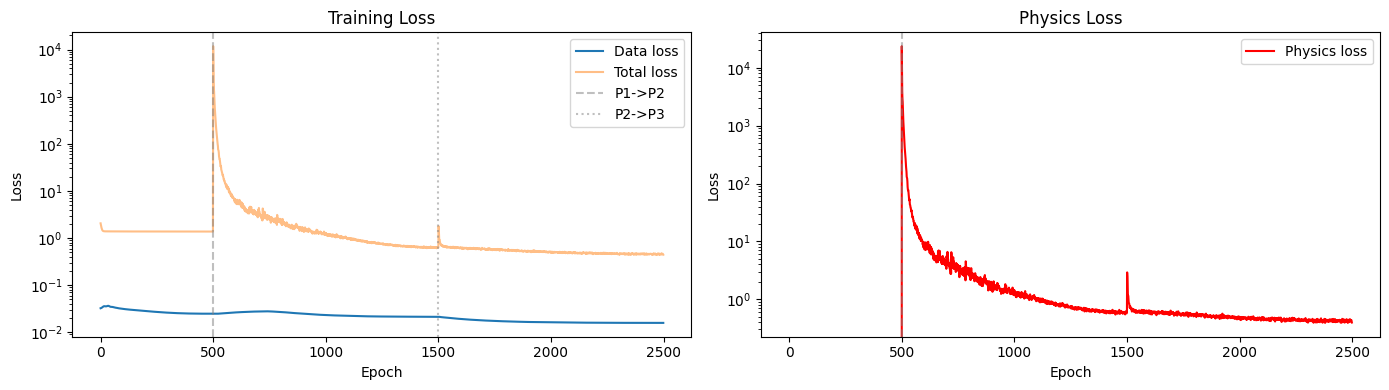

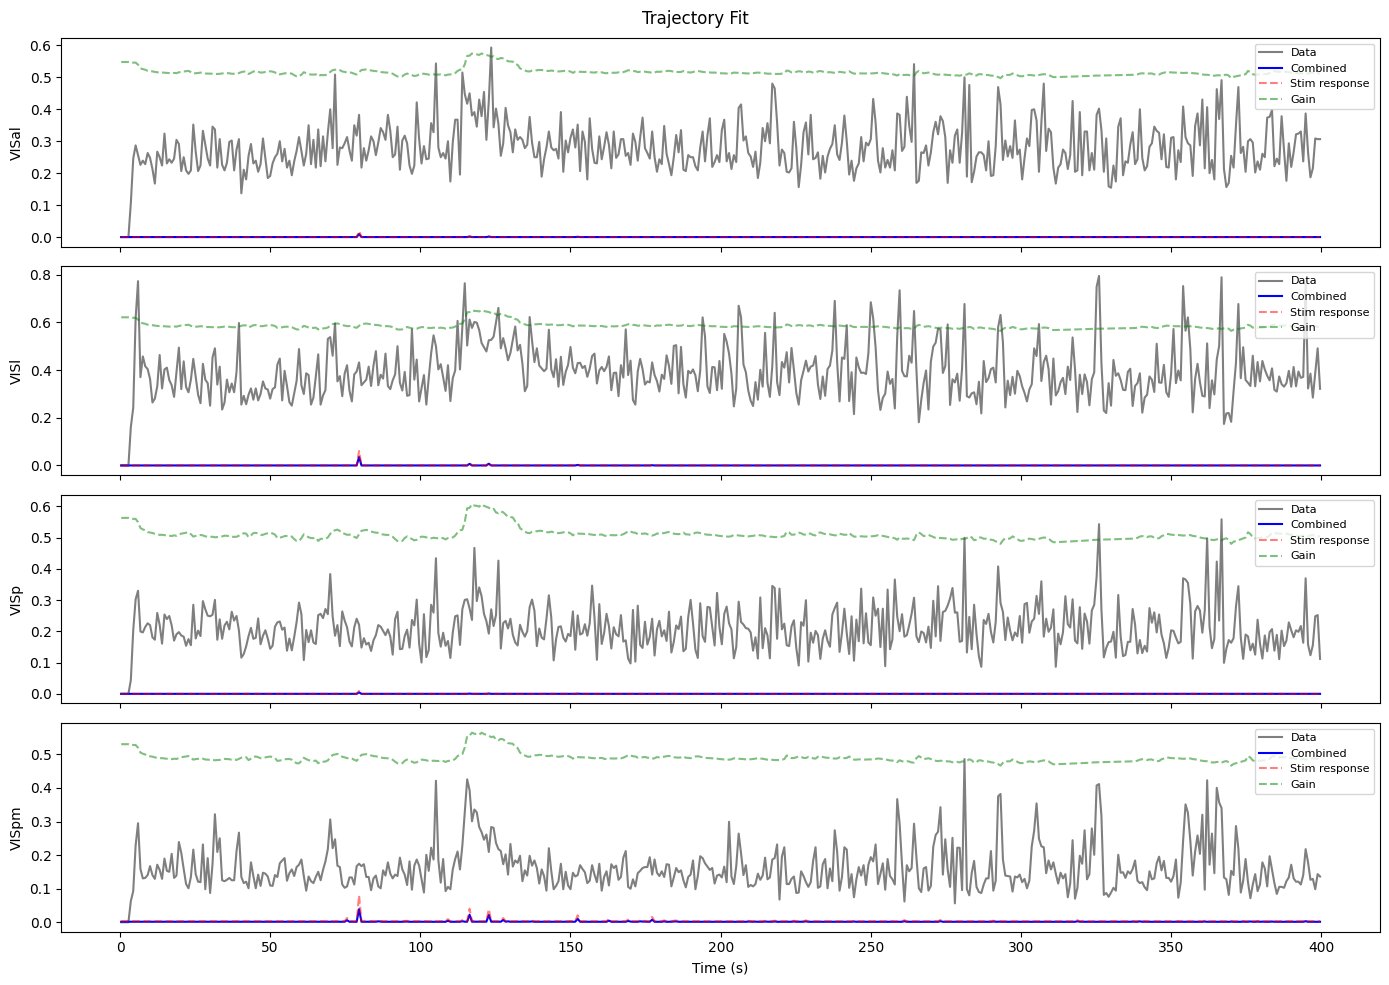

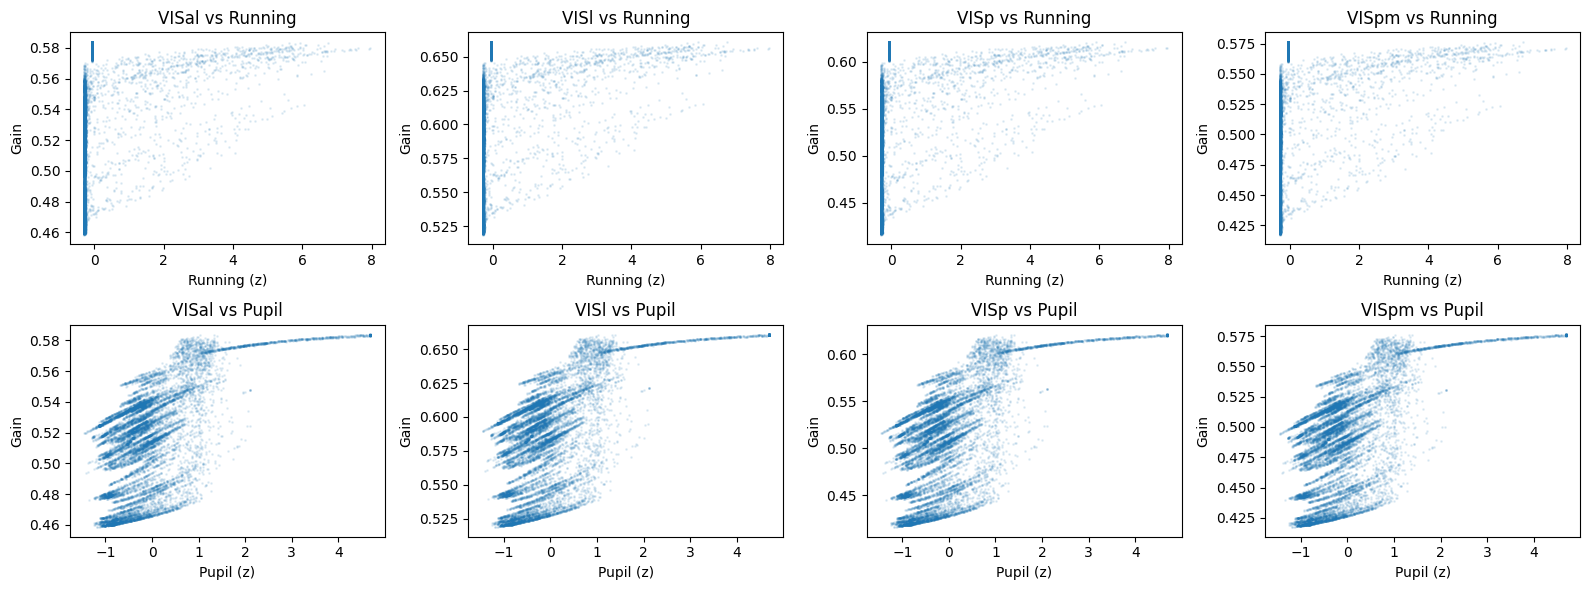

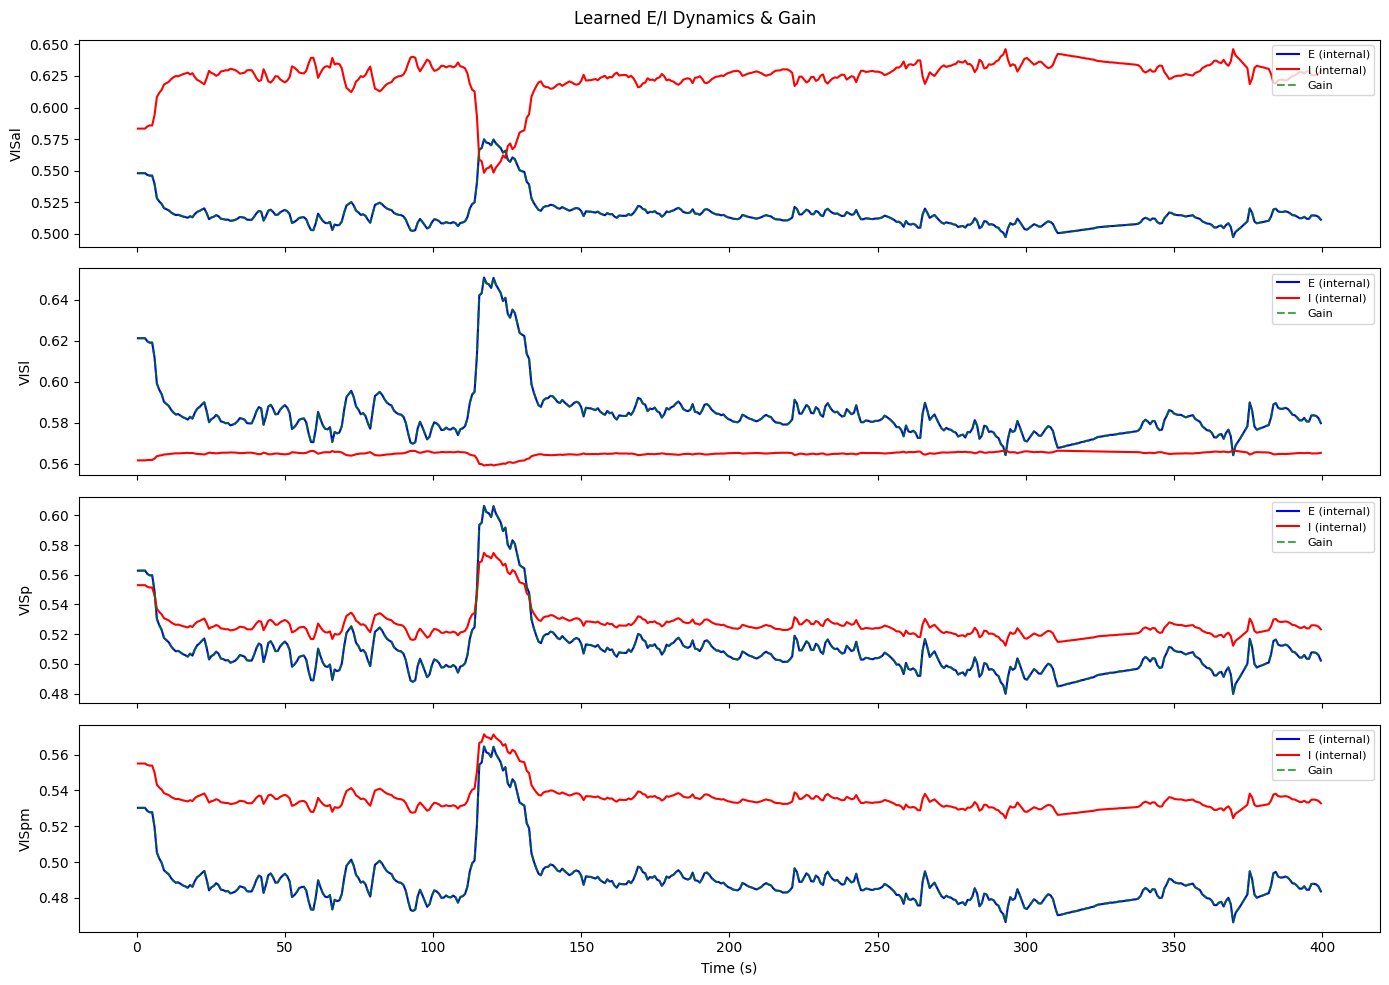


=== Learned WC Parameters ===
tau_E: [1.5015361  1.0745623  0.94562376 1.1954412 ]
tau_I: [1.5939436 1.5960057 1.4341564 1.4602548]
w_EE:  [5.2250285 5.0038514 5.0905514 5.090942 ]
w_EI:  [3.6871    3.9200592 3.9010878 3.9027052]
w_IE:  [2.320489  2.4090085 2.6737955 2.6618485]
w_II:  [1.651642  1.5169399 1.3433288 1.3462563]
a:     [3.666156  3.504797  4.097548  3.9405446]
b_E:   [0.2555757  0.05508629 0.11303081 0.09959857]
b_I:   [-0.6643723  -0.5228261  -0.3635922  -0.34712625]

=== Gain Statistics ===
Mean gain per region: [0.5172616  0.58631307 0.5122441  0.49140367]
Std gain per region:  [0.03384666 0.03838121 0.05544642 0.04280256]
Min gain per region:  [0.4584688  0.5186707  0.41596404 0.41740268]
Max gain per region:  [0.5838905 0.6608837 0.6212104 0.5763529]


In [25]:
# Cell 6: Evaluation & Plots

model.eval()
with torch.no_grad():
    combined, stim_out, E_int, I_int = model(t_tensor, U_tensor, beh_tensor)
    pred = combined.cpu().numpy()
    stim_pred = torch.sigmoid(stim_out).cpu().numpy()
    E_pred = torch.sigmoid(E_int).cpu().numpy()
    I_pred = torch.sigmoid(I_int).cpu().numpy()
    Y_np = Y_tensor.cpu().numpy()

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

print("=== R\u00b2 Scores ===")
print(f"{'Region':<10} {'Combined':>10} {'Stim Only':>10} {'Internal E':>10}")
print("-" * 45)
for i, reg in enumerate(regions):
    r2_comb = r_squared(Y_np[:, i], pred[:, i])
    r2_stim = r_squared(Y_np[:, i], stim_pred[:, i])
    r2_int  = r_squared(Y_np[:, i], E_pred[:, i])
    print(f"{reg:<10} {r2_comb:>10.4f} {r2_stim:>10.4f} {r2_int:>10.4f}")

# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].semilogy(losses_data, label='Data loss')
axes[0].semilogy(losses_total, label='Total loss', alpha=0.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].set_title('Training Loss')
axes[1].semilogy(losses_phys, label='Physics loss', color='red')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].set_title('Physics Loss')
plt.tight_layout(); plt.show()

# Trajectory overlay
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
t_plot = t_ds[:500]
for i, reg in enumerate(regions):
    axes[i].plot(t_plot, Y_np[:500, i], 'k', alpha=0.5, label='Data')
    axes[i].plot(t_plot, pred[:500, i], 'b', label='Combined')
    axes[i].plot(t_plot, stim_pred[:500, i], 'r--', alpha=0.5, label='Stim only')
    axes[i].plot(t_plot, E_pred[:500, i], 'g--', alpha=0.5, label='Internal E')
    axes[i].set_ylabel(reg); axes[i].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Trajectory Fit'); plt.tight_layout(); plt.show()

# E vs I dynamics
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for i, reg in enumerate(regions):
    axes[i].plot(t_plot, E_pred[:500, i], 'b', label='E (internal)')
    axes[i].plot(t_plot, I_pred[:500, i], 'r', label='I (internal)')
    axes[i].set_ylabel(reg); axes[i].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Learned E/I Dynamics'); plt.tight_layout(); plt.show()

# E/I vs behavioral state
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
beh_np = beh_tensor.cpu().numpy()
for i, reg in enumerate(regions):
    axes[0, i].scatter(beh_np[:, 0], E_pred[:, i], s=1, alpha=0.1)
    axes[0, i].set_xlabel('Running (z)'); axes[0, i].set_ylabel(f'E')
    axes[0, i].set_title(f'{reg} vs Running')
    axes[1, i].scatter(beh_np[:, 1], E_pred[:, i], s=1, alpha=0.1)
    axes[1, i].set_xlabel('Pupil (z)'); axes[1, i].set_ylabel(f'E')
    axes[1, i].set_title(f'{reg} vs Pupil')
plt.tight_layout(); plt.show()

# Learned WC parameters
print("\n=== Learned WC Parameters ===")
with torch.no_grad():
    print(f"tau_E: {nn.functional.softplus(wc.tau_E).cpu().numpy()}")
    print(f"tau_I: {nn.functional.softplus(wc.tau_I).cpu().numpy()}")
    print(f"w_EE:  {wc.w_EE.cpu().numpy()}")
    print(f"w_EI:  {wc.w_EI.cpu().numpy()}")
    print(f"w_IE:  {wc.w_IE.cpu().numpy()}")
    print(f"w_II:  {wc.w_II.cpu().numpy()}")
    print(f"a:     {wc.a.cpu().numpy()}")
    print(f"b_E:   {wc.b_E.cpu().numpy()}")
    print(f"b_I:   {wc.b_I.cpu().numpy()}")

print("\n=== E/I Dynamics Statistics ===")
print(f"E_int std per region:  {E_pred.std(axis=0)}")
print(f"I_int std per region:  {I_pred.std(axis=0)}")
print(f"E_int range per region: {E_pred.min(axis=0)} to {E_pred.max(axis=0)}")